# Hermite vs Bernese — RTN comparison

Loads the pre-saved epoch-wise `clean_df` CSVs produced by the hermite and bernese
comparison notebooks, aligns them to a common set of epochs (inner join on
`epoch_datetime`), and analyses the component-wise difference
`delta = bernese − hermite` for a single selected day.

**Input files** (written by the sibling notebooks):
- `clean_df_gop_vs_ssa_<sat>_<doy>.csv` — RTN differences GOP vs SSA (Hermite interpolation)
- `clean_df_bernese_<sat>_<solution>_<doy>.csv` — RTN differences from Bernese `.OUT` files

**Outputs**: time-series overlay, difference series, histogram, and periodograms.

## Imports

Standard library, third-party packages.

In [1]:
# --- Standard library ---
import sys
from pathlib import Path

# --- Third-party packages ---
try:
    import numpy as np
except ImportError as e:
    raise RuntimeError("Missing dependency: numpy. Install with: pip install numpy") from e

try:
    import pandas as pd
    pd.set_option("display.float_format", "{:.5f}".format)
except ImportError as e:
    raise RuntimeError("Missing dependency: pandas. Install with: pip install pandas") from e

try:
    import matplotlib.pyplot as plt
except ImportError as e:
    raise RuntimeError("Missing dependency: matplotlib. Install with: pip install matplotlib") from e

# --- doris package ---
_src = Path("../..").resolve() / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

try:
    from doris.analysis.spectral.periodogram import compute_periodogram
    from doris.output.tables import save_latex_table, Col
except ImportError as e:
    raise RuntimeError(
        "Missing doris modules. Make sure the project src path is on PYTHONPATH."
    ) from e

print("CWD:", Path.cwd())


CWD: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\notebooks\satellites


## Paths and parameters

Point to the two input CSVs and set the output folder.
Both files are produced by running the hermite / bernese sibling notebooks first.

In [2]:
PROJECT_ROOT = Path("../..").resolve()
RESULTS_DIR  = PROJECT_ROOT / "data" / "results"

# --- Satellite selection ---
# cs2->CR  h2c->HC  h2d->HD  ja3->J3  s3a->AS  s3b->BS  s6a->S6  srl->SA
SAT_HERMITE = "srl"

_SAT_TO_BERNESE = {
    "cs2": "CR", "h2c": "HC", "h2d": "HD",
    "ja3": "J3", "s3a": "AS", "s3b": "BS",
    "s6a": "S6", "srl": "SA",
}
SAT_BERNESE = _SAT_TO_BERNESE[SAT_HERMITE]

# --- Output folders ---
FIGURES_DIR = PROJECT_ROOT / "LaTeX" / "images" / "results" / "satellites" / "comparison" / SAT_HERMITE
TABLES_DIR  = PROJECT_ROOT / "LaTeX" / "tables" / "results" / "satellites" / "comparison" / SAT_HERMITE
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# --- Input CSV files ---
HERMITE_CSV = RESULTS_DIR / f"clean_df_gop_vs_ssa_{SAT_HERMITE}_doy001.csv"
BERNESE_CSV = RESULTS_DIR / f"clean_df_bernese_{SAT_BERNESE.lower()}_ZAZG_doy001.csv"

# --- Labels ---
HERMITE_LABEL = "Hermite"
BERNESE_LABEL = "Bernese"
FILE_TAG      = "hermite_vs_bernese"

_sat_display = SAT_HERMITE.upper()

print("SAT_HERMITE :", SAT_HERMITE, "-> SAT_BERNESE:", SAT_BERNESE)
print("HERMITE_CSV :", HERMITE_CSV, "| exists:", HERMITE_CSV.exists())
print("BERNESE_CSV :", BERNESE_CSV, "| exists:", BERNESE_CSV.exists())
print("FIGURES_DIR :", FIGURES_DIR)
print("TABLES_DIR  :", TABLES_DIR)


SAT_HERMITE : srl -> SAT_BERNESE: SA
HERMITE_CSV : C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\results\clean_df_gop_vs_ssa_srl_doy001.csv | exists: True
BERNESE_CSV : C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\results\clean_df_bernese_sa_ZAZG_doy001.csv | exists: True
FIGURES_DIR : C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\comparison\srl
TABLES_DIR  : C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\results\satellites\comparison\srl


## Load and align

Read both CSVs, parse timestamps, and inner-join on `epoch_datetime` to obtain
a common set of epochs. The bernese dataset typically has a coarser sampling
(300 s) than the hermite dataset (60 s), so the aligned set follows the bernese cadence.

In [3]:
df_h = pd.read_csv(HERMITE_CSV, parse_dates=["epoch_datetime"])
df_b = pd.read_csv(BERNESE_CSV, parse_dates=["epoch_datetime"])

# Round to the nearest second to avoid sub-second mismatches.
df_h["epoch_datetime"] = df_h["epoch_datetime"].dt.round("1s")
df_b["epoch_datetime"] = df_b["epoch_datetime"].dt.round("1s")

# Inner join — keep only epochs present in both datasets.
df = df_h.merge(
    df_b,
    on="epoch_datetime",
    suffixes=("_h", "_b"),
    how="inner",
).sort_values("epoch_datetime").reset_index(drop=True)

print(f"Hermite rows  : {len(df_h)}")
print(f"Bernese rows  : {len(df_b)}")
print(f"Aligned rows  : {len(df)}")
print(f"From          : {df['epoch_datetime'].min()}")
print(f"To            : {df['epoch_datetime'].max()}")

# Sampling diagnostics on the aligned series.
_dt = df["epoch_datetime"].diff().dt.total_seconds()
print(f"Step [s]      : median={_dt.median():.0f}, max={_dt.max():.0f}")

# DOY label for filenames.
_doy = df["epoch_datetime"].iloc[0].timetuple().tm_yday
_doy_str = f"doy{_doy:03d}"

display(df.head())


Hermite rows  : 1440
Bernese rows  : 288
Aligned rows  : 160
From          : 2024-01-01 00:00:00
To            : 2024-01-01 23:55:00
Step [s]      : median=300, max=900


,epoch_datetime,dR_h,dT_h,dN_h,d3D_h,dR_b,dT_b,dN_b,d3D_b
0,2024-01-01 00:00:00,9.74893,-10.05009,-16.38883,21.55550,8.50000,-5.83000,-16.40000,19.37005
1,2024-01-01 00:15:00,5.27871,-19.75154,6.89696,21.57675,4.06000,-17.53000,4.42000,18.52892
2,2024-01-01 00:20:00,1.96304,-19.08598,11.32526,22.27980,0.98000,-17.99000,9.60000,20.41471
3,2024-01-01 00:35:00,-7.32312,-10.01226,13.98778,18.69575,-7.15000,-8.53000,14.58000,18.34284
4,2024-01-01 00:40:00,-6.94164,-5.18542,12.49531,15.20551,-8.04000,-3.27000,13.22000,15.81464


## Compute differences

For each RTN component compute `delta = bernese − hermite`.
A positive delta means the bernese RTN difference is larger than the hermite one.

In [4]:
df["ddR"] = df["dR_b"] - df["dR_h"]
df["ddT"] = df["dT_b"] - df["dT_h"]
df["ddN"] = df["dN_b"] - df["dN_h"]
df["dd3D"] = np.sqrt(df["ddR"]**2 + df["ddT"]**2 + df["ddN"]**2)

t_hours = (df["epoch_datetime"] - df["epoch_datetime"].iloc[0]).dt.total_seconds() / 3600.0

def _rms(arr): return float(np.sqrt(np.mean(arr**2))) if len(arr) else float("nan")

for comp, col in [("R", "ddR"), ("T", "ddT"), ("N", "ddN"), ("3D", "dd3D")]:
    print(f"delta {comp}  — střední hodnota: {df[col].mean():.3f} mm,  RMS: {_rms(df[col].values):.3f} mm")


delta R  — střední hodnota: -0.101 mm,  RMS: 0.852 mm
delta T  — střední hodnota: 1.980 mm,  RMS: 2.626 mm
delta N  — střední hodnota: 0.043 mm,  RMS: 1.255 mm
delta 3D  — střední hodnota: 2.692 mm,  RMS: 3.032 mm


## RTN time series — overlay

Both datasets plotted on the same axes for a direct visual comparison.

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\comparison\srl\hermite_vs_bernese_doy001_rtn_overlay  [.pdf + .png]


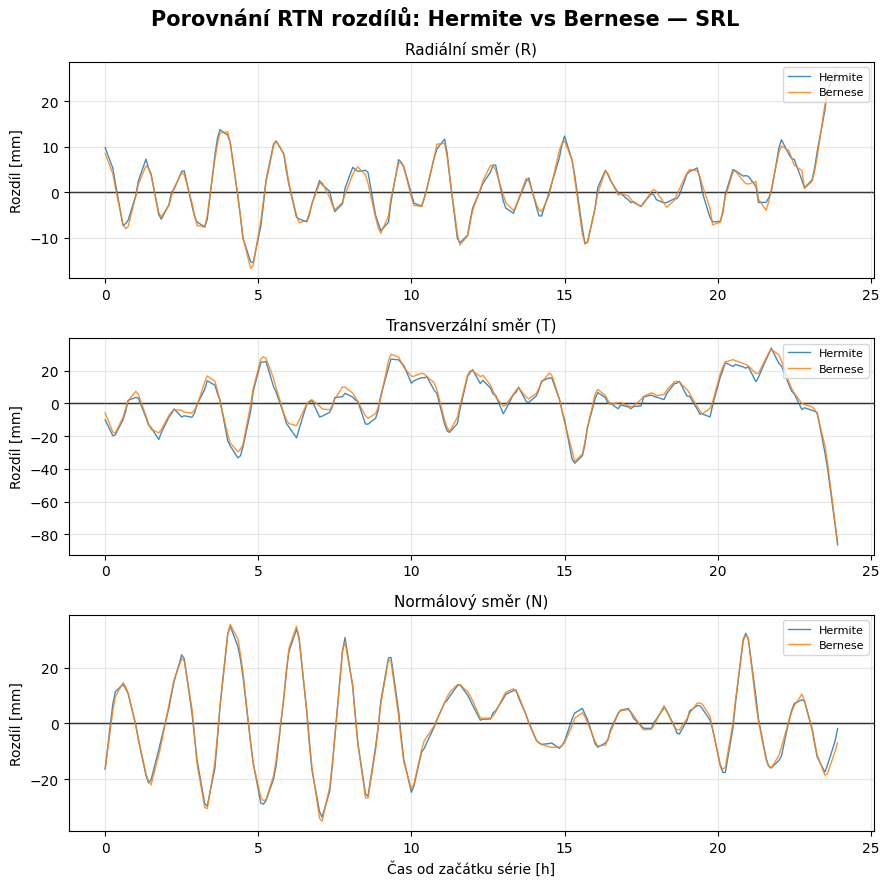

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

for ax, (col, title) in zip(axes, components):
    ax.plot(t_hours, df[f"{col}_h"].values, linewidth=1.0, label=HERMITE_LABEL, alpha=0.85)
    ax.plot(t_hours, df[f"{col}_b"].values, linewidth=1.0, label=BERNESE_LABEL, alpha=0.85)
    ax.axhline(0, color="black", linewidth=1.0, zorder=0)
    ax.set_ylabel("Rozdíl [mm]")
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Čas od začátku série [h]")
fig.suptitle(f"Porovnání RTN rozdílů: Hermite vs Bernese — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{FILE_TAG}_{_doy_str}_rtn_overlay"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## RTN difference series (Bernese − Hermite)

Epoch-wise difference `delta = bernese − hermite` per component.

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\comparison\srl\hermite_vs_bernese_doy001_rtn_differences  [.pdf + .png]


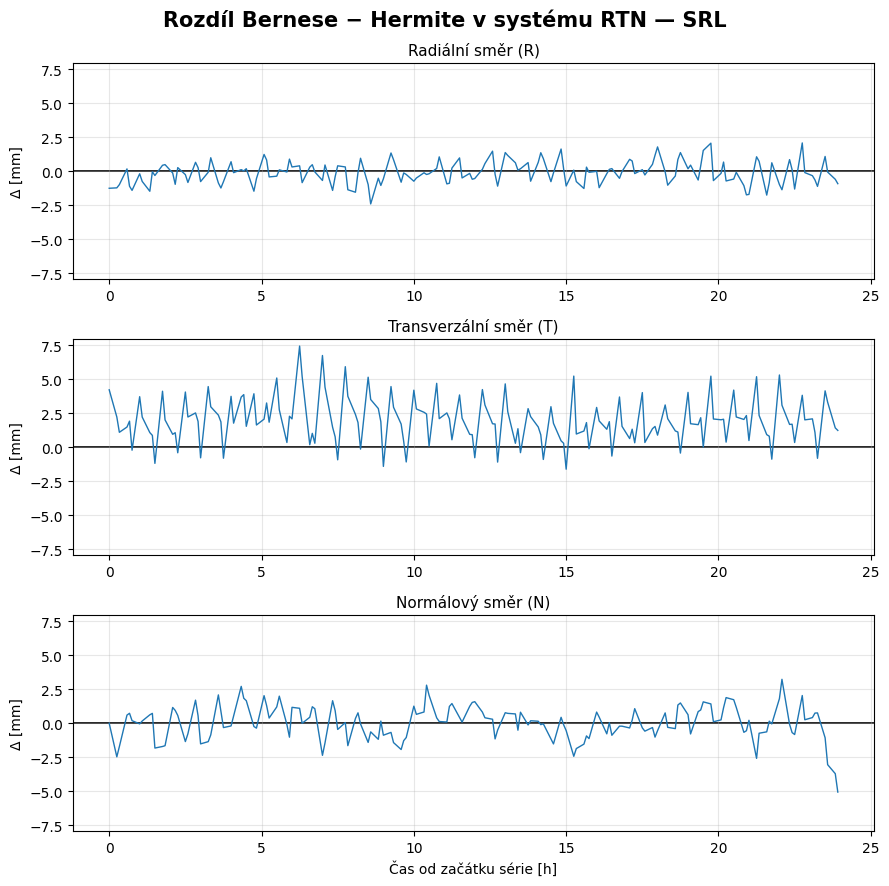

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components_dd = [
    ("ddR", "Radiální směr (R)"),
    ("ddT", "Transverzální směr (T)"),
    ("ddN", "Normálový směr (N)"),
]

max_abs = np.max(np.abs(df[["ddR", "ddT", "ddN"]].values))
ylim = (-max_abs - 0.5, max_abs + 0.5)

for ax, (col, title) in zip(axes, components_dd):
    ax.plot(t_hours, df[col].values, linewidth=1.0)
    ax.axhline(0, color="black", linewidth=1.2, zorder=0)
    ax.set_ylabel("Δ [mm]")
    ax.set_title(title, fontsize=11)
    ax.set_ylim(ylim)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Čas od začátku série [h]")
fig.suptitle(f"Rozdíl Bernese − Hermite v systému RTN — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{FILE_TAG}_{_doy_str}_rtn_differences"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## Difference histogram (Bernese − Hermite)

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\comparison\srl\hermite_vs_bernese_doy001_rtn_histogram  [.pdf + .png]


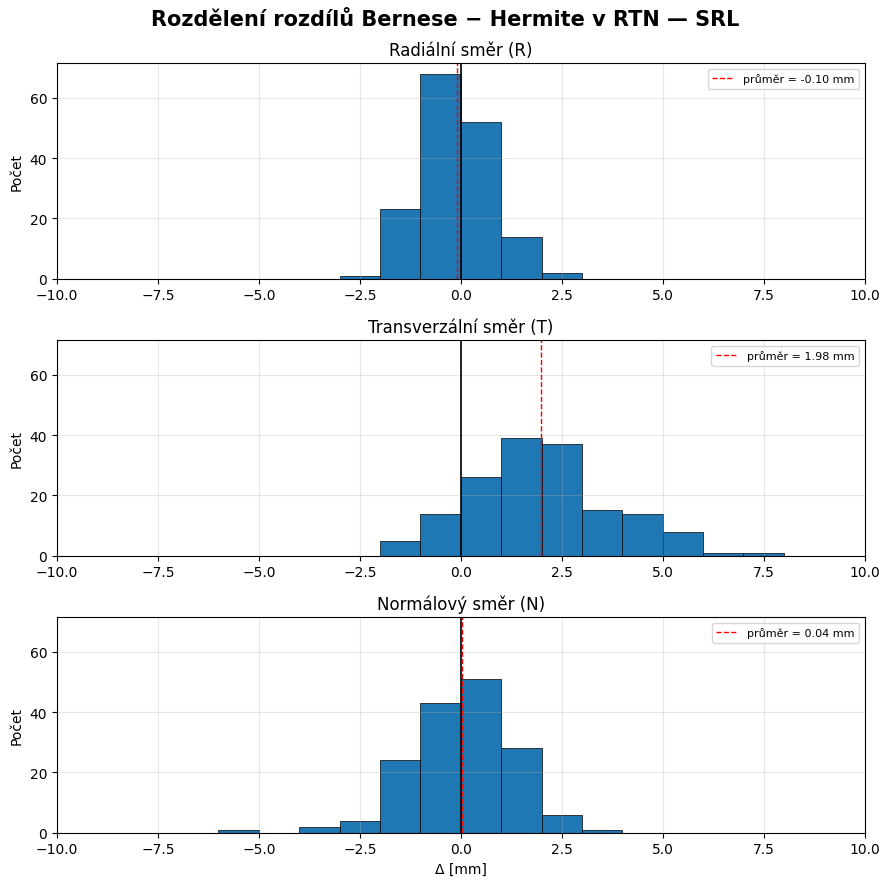

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components_dd = [
    ("ddR", "Radiální směr (R)"),
    ("ddT", "Transverzální směr (T)"),
    ("ddN", "Normálový směr (N)"),
]

max_abs = np.max(np.abs(df[["ddR", "ddT", "ddN"]].values))
xmax = np.ceil(max_abs / 5) * 5
bins = np.arange(-xmax, xmax + 1, 1)

for ax, (col, title) in zip(axes, components_dd):
    ax.hist(df[col].values, bins=bins, edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=1.2)
    ax.axvline(df[col].mean(), color="red", linewidth=1.0, linestyle="--",
               label=f"průměr = {df[col].mean():.2f} mm")
    ax.set_ylabel("Počet")
    ax.set_title(title)
    ax.set_xlim(-xmax, xmax)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Δ [mm]")
fig.suptitle(f"Rozdělení rozdílů Bernese − Hermite v RTN — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{FILE_TAG}_{_doy_str}_rtn_histogram"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## Periodogram — Lomb-Scargle (Bernese − Hermite)

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\comparison\srl\hermite_vs_bernese_doy001_rtn_periodograms_lomb_scargle  [.pdf + .png]


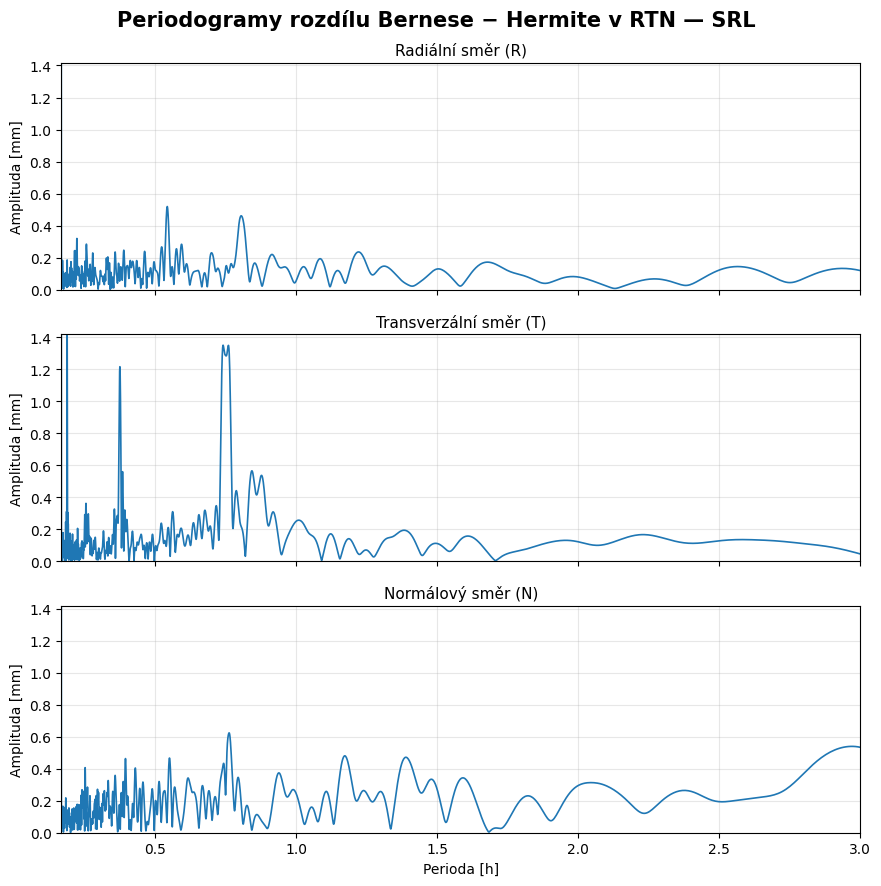

In [8]:
t = (df["epoch_datetime"] - df["epoch_datetime"].iloc[0]).dt.total_seconds().values

components_dd = [
    ("ddR", "Radiální směr (R)"),
    ("ddT", "Transverzální směr (T)"),
    ("ddN", "Normálový směr (N)"),
]

MIN_PERIOD_S = 10 * 60
MAX_PERIOD_S = 3 * 3600

periodograms = {}
global_max = 0

for col, _ in components_dd:
    pgram = compute_periodogram(
        t, df[col].values,
        method="lomb_scargle",
        min_period=MIN_PERIOD_S,
        max_period=MAX_PERIOD_S,
    )
    periodograms[col] = pgram
    local_max = pgram.loc[pgram["period"] / 3600 > 0.5, "amplitude"].max()
    if local_max > global_max:
        global_max = local_max

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, (col, title) in zip(axes, components_dd):
    pgram = periodograms[col]
    periods_h = pgram["period"] / 3600
    ax.plot(periods_h, pgram["amplitude"], linewidth=1.2, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Amplituda [mm]")
    ax.set_ylim(0, global_max * 1.05)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Perioda [h]")
axes[-1].set_xlim(MIN_PERIOD_S / 3600, MAX_PERIOD_S / 3600)
fig.suptitle(f"Periodogramy rozdílu Bernese − Hermite v RTN — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{FILE_TAG}_{_doy_str}_rtn_periodograms_lomb_scargle"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## Periodogram — FFT (Bernese − Hermite)

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\comparison\srl\hermite_vs_bernese_doy001_rtn_periodograms_fft  [.pdf + .png]


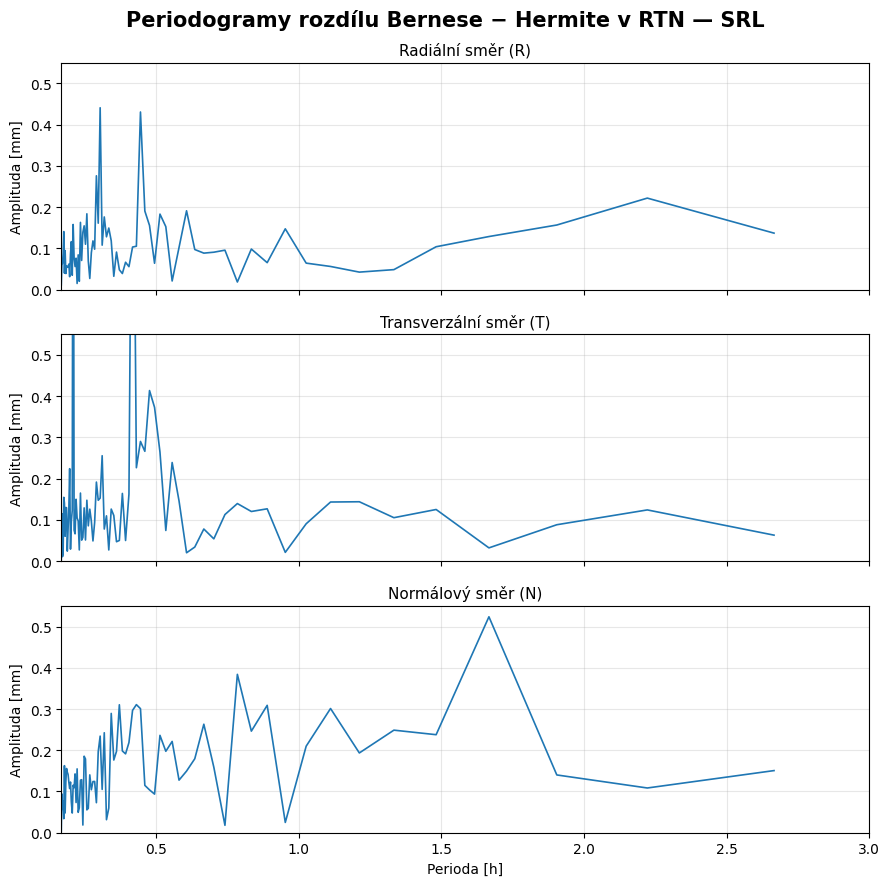

In [9]:
t = (df["epoch_datetime"] - df["epoch_datetime"].iloc[0]).dt.total_seconds().values

components_dd = [
    ("ddR", "Radiální směr (R)"),
    ("ddT", "Transverzální směr (T)"),
    ("ddN", "Normálový směr (N)"),
]

MIN_PERIOD_S = 10 * 60
MAX_PERIOD_S = 3 * 3600

periodograms = {}
global_max = 0

for col, _ in components_dd:
    pgram = compute_periodogram(
        t, df[col].values,
        method="fft",
        min_period=MIN_PERIOD_S,
        max_period=MAX_PERIOD_S,
    )
    periodograms[col] = pgram
    local_max = pgram.loc[pgram["period"] / 3600 > 0.5, "amplitude"].max()
    if local_max > global_max:
        global_max = local_max

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

for ax, (col, title) in zip(axes, components_dd):
    pgram = periodograms[col]
    periods_h = pgram["period"] / 3600
    ax.plot(periods_h, pgram["amplitude"], linewidth=1.2, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Amplituda [mm]")
    ax.set_ylim(0, global_max * 1.05)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Perioda [h]")
axes[-1].set_xlim(MIN_PERIOD_S / 3600, MAX_PERIOD_S / 3600)
fig.suptitle(f"Periodogramy rozdílu Bernese − Hermite v RTN — {_sat_display}", fontsize=15, fontweight="bold")

plt.tight_layout()
_stem = FIGURES_DIR / f"{FILE_TAG}_{_doy_str}_rtn_periodograms_fft"
fig.savefig(_stem.with_suffix(".pdf"), bbox_inches="tight")
fig.savefig(_stem.with_suffix(".png"), bbox_inches="tight", dpi=150)
print(f"Uloženo: {_stem}  [.pdf + .png]")
plt.show()


## Summary statistics

In [10]:
def _rms(arr): return float(np.sqrt(np.mean(arr**2))) if len(arr) else float("nan")

rows = []
for comp, col_h, col_b, col_d in [
    ("R", "dR_h", "dR_b", "ddR"),
    ("T", "dT_h", "dT_b", "ddT"),
    ("N", "dN_h", "dN_b", "ddN"),
]:
    h = df[col_h].to_numpy()
    b = df[col_b].to_numpy()
    d = df[col_d].to_numpy()
    rows.append({
        "component":       comp,
        "hermite_rms_mm":  _rms(h),
        "bernese_rms_mm":  _rms(b),
        "delta_mean_mm":   d.mean(),
        "delta_rms_mm":    _rms(d),
        "delta_rms0_mm":   _rms(d - d.mean()),
    })

summary = pd.DataFrame(rows)
display(summary.round(3))

,component,hermite_rms_mm,bernese_rms_mm,delta_mean_mm,delta_rms_mm,delta_rms0_mm
0,R,6.95000,6.84400,-0.10100,0.85200,0.84600
1,T,17.33200,17.36300,1.98000,2.62600,1.72500
2,N,14.56200,14.63100,0.04300,1.25500,1.25400


In [11]:
_sum_cols = [
    Col("component",      "Složka",                          None),
    Col("hermite_rms_mm", r"RMS$_\mathrm{H}$ [mm]",         3),
    Col("bernese_rms_mm", r"RMS$_\mathrm{B}$ [mm]",         3),
    Col("delta_mean_mm",  r"$\bar{\Delta}$ [mm]",            3),
    Col("delta_rms_mm",   r"RMS$_{\Delta}$ [mm]",            3),
    Col("delta_rms0_mm",  r"RMS$_{0,\Delta}$ [mm]",          3),
]
_table_path = TABLES_DIR / f"{FILE_TAG}_{_doy_str}_summary.tex"
save_latex_table(
    summary, _table_path, cols=_sum_cols,
    caption=f"Souhrnné statistiky rozdílů a jejich shoda — {_sat_display}, den {_doy_str}",
    label=f"tab:{FILE_TAG}_{SAT_HERMITE}_{_doy_str}_summary",
    print_preview=True,
)
print(f"Uloženo: {_table_path}")

\begin{table}[H]
\centering
\caption{Souhrnné statistiky rozdílů a jejich shoda — SRL, den doy001}
\label{tab:hermite_vs_bernese_srl_doy001_summary}
\begin{tabular}{lrrrrr}
\toprule
Složka & RMS$_\mathrm{H}$ [mm] & RMS$_\mathrm{B}$ [mm] & $\bar{\Delta}$ [mm] & RMS$_{\Delta}$ [mm] & RMS$_{0,\Delta}$ [mm] \\
\midrule
R & 6.950 & 6.844 & -0.101 & 0.852 & 0.846 \\
T & 17.332 & 17.363 & 1.980 & 2.626 & 1.725 \\
N & 14.562 & 14.631 & 0.043 & 1.255 & 1.254 \\
\bottomrule
\end{tabular}
\end{table}

Uloženo: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\tables\results\satellites\comparison\srl\hermite_vs_bernese_doy001_summary.tex
